In [9]:
import pandas as pd
df = pd.read_excel('terrains.xlsx')

In [2]:
df.head()

,source,id,quartier,quartier_norm,price_dh,surface_m2,price_per_m2,quartier_clean
0,mubawab,8337876,Sidi Maarouf,sidi maarouf,22000000,810,27160.5,Sidi Maarouf
1,mubawab,8351797,Ain Diab Extension,ain diab extension,7500000,603,12437.8,Ain Diab Extension
2,mubawab,8328372,Californie,californie,10570000,919,11501.6,Californie
3,mubawab,8364043,Almaz,almaz,3291800,302,10900.0,Almaz
4,mubawab,8372174,Californie,californie,55000000,6800,8088.2,Californie


In [2]:
df = df[df["quartier_clean"] != "Autre Secteur"]

In [4]:
df.describe()

,id,price_dh,surface_m2,price_per_m2
count,7.600000e+02,7.600000e+02,760.000000,7.600000e+02
mean,3.030918e+07,1.854792e+07,4243.847368,1.775660e+04
std,2.502832e+07,2.569387e+07,12884.707619,7.168726e+04
min,7.950000e+02,3.750000e+05,70.000000,1.000000e+03
25%,8.066607e+06,4.837500e+06,377.750000,8.012675e+03
50%,8.352354e+06,1.094750e+07,698.500000,1.200000e+04
75%,5.726921e+07,2.087325e+07,1438.750000,1.968138e+04
max,5.815664e+07,2.400000e+08,120000.000000,1.791045e+06


<Axes: xlabel='price_dh', ylabel='Count'>

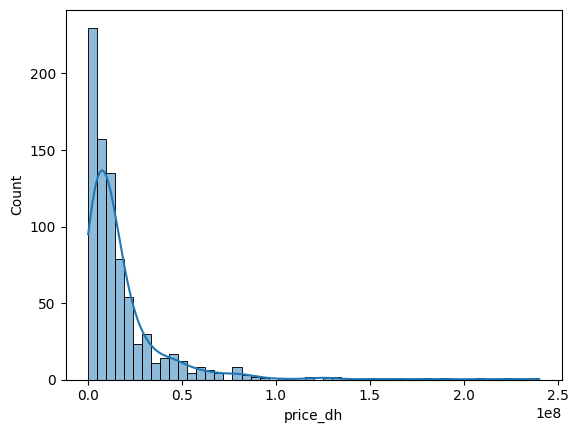

In [12]:
# distribution du prix m2 avec seaborn
import seaborn as sns
sns.histplot(df['price_dh'], bins=50, kde=True)

In [13]:
# suppression des vals aberrantes 

col = "price_dh"
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df = df[df[col] <= upper_bound]

<Axes: xlabel='price_dh', ylabel='Count'>

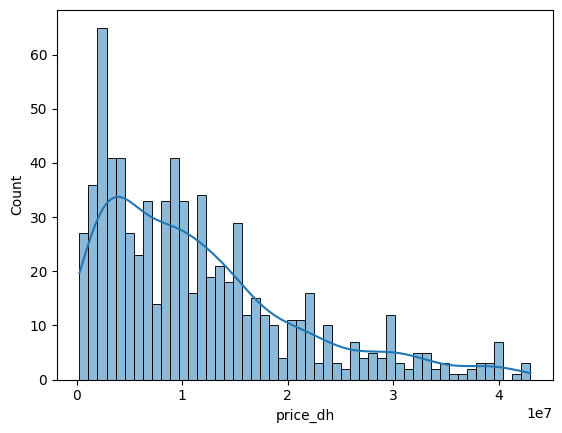

In [14]:
# distribution du prix m2 avec seaborn
import seaborn as sns
sns.histplot(df['price_dh'], bins=50, kde=True)

<Axes: xlabel='surface_m2', ylabel='Count'>

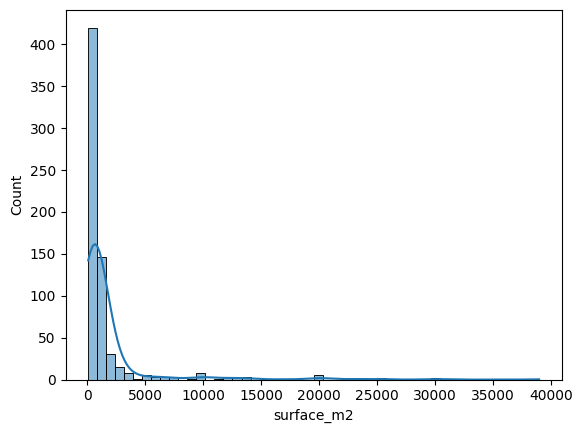

In [8]:
sns.histplot(df['surface_m2'], bins=50, kde=True)

In [15]:
col = "surface_m2"
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df = df[df[col] <= upper_bound]

<Axes: xlabel='surface_m2', ylabel='Count'>

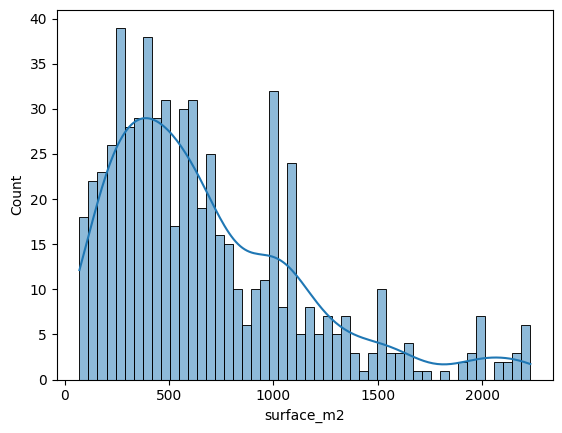

In [19]:
sns.histplot(df['surface_m2'], bins=50, kde=True)

In [17]:
# la fréquence de chaque quartier
freq = df["quartier_clean"].value_counts()

# quartiers avec >= 10 annonces
freq_10plus = freq[freq >= 10]

print(freq_10plus.to_string())

quartier_clean
Ain Diab              67
Sidi Maarouf          56
Ain Sebaa             49
Californie            48
Autre Secteur         44
Anfa                  39
Oasis                 36
Almaz                 33
Maarif                25
Nassim                25
Oulfa                 24
Lissasfa              18
Ain Diab Extension    17
Casablanca            15
Ferme Bretonne        14
Franceville           14
Cil                   13
Ain Chock             13
Sidi Moumen           13
Beausejour            12
Riviera               12
Polo                  11
Longchamps            11
Palmier               10
Hay Hassani           10


In [18]:
# Supprimer les quartiers moins de 10 occurrences 
counts = df['quartier_clean'].value_counts()
df = df[df['quartier_clean'].isin(counts[counts >= 10].index)].copy()


In [20]:
df= df[['quartier_clean','surface_m2', 'price_dh']]

In [21]:
df

,quartier_clean,surface_m2,price_dh
0,Sidi Maarouf,810,22000000
1,Ain Diab Extension,603,7500000
2,Californie,919,10570000
3,Almaz,302,3291800
6,Ain Diab,1065,12600000
...,...,...,...
805,Anfa,2122,23345000
806,Anfa,1577,28386000
807,Anfa,1425,25650000
808,Franceville,104,375000


In [39]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

cat_cols = ['quartier_clean']
num_cols = ['surface_m2']



X = df[cat_cols + num_cols].copy()
y = df['price_dh'] * 0.9

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = enc.fit_transform(X[cat_cols])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=df.loc[y.index, 'quartier_clean']
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

results = {}

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2   = r2_score(y_te, pred)
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"{name:30s} | MAE={mae:,.0f}  RMSE={rmse:,.0f}  R2={r2:.4f}")
    return model


Train: (503, 2), Test: (126, 2)


In [42]:
import joblib

joblib.dump(enc, "models/ordinal_encoder_quartiers_terrains.pkl")

['models/ordinal_encoder_quartiers_terrains.pkl']

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

ridge = evaluate("Ridge (alpha=10)",
                 Pipeline([("sc", StandardScaler()), ("m", Ridge(alpha=10))]),
                 X_train, y_train, X_test, y_test)


Ridge (alpha=10)               | MAE=3,396,132  RMSE=4,915,679  R2=0.5211


In [25]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

dt = evaluate("Decision Tree",
              DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=42),
              X_train, y_train, X_test, y_test)

rf = evaluate("Random Forest",
              RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                    n_jobs=-1, random_state=42),
              X_train, y_train, X_test, y_test)


Decision Tree                  | MAE=2,814,976  RMSE=4,685,417  R2=0.5649
Random Forest                  | MAE=2,599,208  RMSE=4,227,075  R2=0.6459


In [26]:
import lightgbm as lgb

lgbm = evaluate("LightGBM",
                lgb.LGBMRegressor(
                    n_estimators=1000, learning_rate=0.05, num_leaves=31,
                    min_child_samples=10, subsample=0.8, colsample_bytree=0.8,
                    reg_alpha=0.1, reg_lambda=1.0, random_state=42,
                    n_jobs=-1, verbose=-1
                ),
                X_train, y_train, X_test, y_test)


LightGBM                       | MAE=2,693,768  RMSE=4,837,251  R2=0.5362


In [28]:
from catboost import CatBoostRegressor, Pool

X_cat = df[cat_cols + num_cols].copy()
y_cat = df["price_dh"] * 0.9

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat, y_cat, test_size=0.2, random_state=42,
    stratify=df.loc[y_cat.index, "quartier_clean"]
)

cat_indices = [X_cat.columns.get_loc(c) for c in cat_cols]

cb = CatBoostRegressor(
    iterations=1000, learning_rate=0.05, depth=8,
    l2_leaf_reg=3, loss_function="RMSE", random_seed=42, verbose=0
)
cb.fit(X_train_cat, y_train_cat, cat_features=cat_indices)

pred_cb = cb.predict(X_test_cat)
mae_cb  = mean_absolute_error(y_test_cat, pred_cb)
rmse_cb = np.sqrt(mean_squared_error(y_test_cat, pred_cb))
r2_cb   = r2_score(y_test_cat, pred_cb)
results["CatBoost"] = {"MAE": mae_cb, "RMSE": rmse_cb, "R2": r2_cb}
print(f"{"CatBoost":30s} | MAE={mae_cb:,.0f}  RMSE={rmse_cb:,.0f}  R2={r2_cb:.4f}")


CatBoost                       | MAE=2,975,435  RMSE=5,015,420  R2=0.5015


In [33]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from catboost import Pool, CatBoostRegressor

X_cv = df[cat_cols + num_cols].copy()

for c in cat_cols:
    X_cv[c] = X_cv[c].fillna('Inconnu')

y_cv = df['price_dh'] * 0.9
strat_groups = df['quartier_clean'].values
quartier_encoded = LabelEncoder().fit_transform(strat_groups)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_maes, cv_rmses, cv_r2s = [], [], []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_cv, quartier_encoded)):
    X_tr_f, X_val_f = X_cv.iloc[tr_idx], X_cv.iloc[val_idx]
    y_tr_f, y_val_f = y_cv.iloc[tr_idx], y_cv.iloc[val_idx]

    pool_tr  = Pool(X_tr_f,  y_tr_f,  cat_features=cat_cols)
    pool_val = Pool(X_val_f, y_val_f, cat_features=cat_cols)

    cb_cv = CatBoostRegressor(
        iterations=1000, learning_rate=0.05, depth=8,
        l2_leaf_reg=3, loss_function='RMSE', random_seed=42, verbose=0
    )
    cb_cv.fit(pool_tr, eval_set=pool_val, early_stopping_rounds=50)

    pred_val = cb_cv.predict(X_val_f)
    cv_maes.append(mean_absolute_error(y_val_f, pred_val))
    cv_rmses.append(np.sqrt(mean_squared_error(y_val_f, pred_val)))
    cv_r2s.append(r2_score(y_val_f, pred_val))
    print(f"  Fold {fold+1} | MAE={cv_maes[-1]:,.0f}  RMSE={cv_rmses[-1]:,.0f}  R²={cv_r2s[-1]:.4f}")

print(f"\n{'CV moyen':30s} | MAE={np.mean(cv_maes):,.0f} ± {np.std(cv_maes):,.0f}"
      f"  RMSE={np.mean(cv_rmses):,.0f} ± {np.std(cv_rmses):,.0f}"
      f"  R²={np.mean(cv_r2s):.4f} ± {np.std(cv_r2s):.4f}")

  Fold 1 | MAE=2,790,163  RMSE=4,172,997  R²=0.5865
  Fold 2 | MAE=3,035,687  RMSE=4,351,666  R²=0.5713
  Fold 3 | MAE=2,992,780  RMSE=4,358,938  R²=0.5884
  Fold 4 | MAE=2,800,692  RMSE=4,257,792  R²=0.6134
  Fold 5 | MAE=3,274,737  RMSE=5,825,848  R²=0.5204

CV moyen                       | MAE=2,978,812 ± 177,942  RMSE=4,593,448 ± 619,953  R²=0.5760 ± 0.0309


In [35]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'iterations':       trial.suggest_int('iterations', 500, 2000),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth':            trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg':      trial.suggest_float('l2_leaf_reg', 1, 10, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength':  trial.suggest_float('random_strength', 0.0, 2.0),
        'border_count':     trial.suggest_int('border_count', 32, 255),
        'loss_function': 'RMSE',
        'random_seed': 42,
        'verbose': 0,
    }

    fold_rmses = []
    for tr_idx, val_idx in skf.split(X_cv, quartier_encoded):
        X_tr_f, X_val_f = X_cv.iloc[tr_idx], X_cv.iloc[val_idx]
        y_tr_f, y_val_f = y_cv.iloc[tr_idx], y_cv.iloc[val_idx]

        model = CatBoostRegressor(**params)
        model.fit(
            Pool(X_tr_f, y_tr_f, cat_features=cat_cols),
            eval_set=Pool(X_val_f, y_val_f, cat_features=cat_cols),
            early_stopping_rounds=50,
        )
        pred = model.predict(X_val_f)
        fold_rmses.append(np.sqrt(mean_squared_error(y_val_f, pred)))

    return np.mean(fold_rmses)

study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=15, show_progress_bar=True)

print(f"\nMeilleur RMSE CV : {study.best_value:,.0f}")
print("Meilleurs hyperparamètres :")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

c:\Users\del\Desktop\prix-immobilier-evaluation\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 12. Best value: 4.50593e+06: 100%|██████████| 15/15 [08:05<00:00, 32.35s/it]


Meilleur RMSE CV : 4,505,931
Meilleurs hyperparamètres :
  iterations: 1479
  learning_rate: 0.08094991577483082
  depth: 5
  l2_leaf_reg: 9.955064057799708
  bagging_temperature: 0.2158360407128856
  random_strength: 1.369679137924054
  border_count: 103


In [37]:
# Ré-entraînement du meilleur modèle sur tout le train
best_params = study.best_params.copy()
best_params.update({'loss_function': 'RMSE', 'random_seed': 42, 'verbose': 0})

cb_best = CatBoostRegressor(**best_params)
cb_best.fit(
    Pool(X_train_cat, y_train_cat, cat_features=cat_cols),
    eval_set=Pool(X_test_cat, y_test_cat, cat_features=cat_cols),
    early_stopping_rounds=50,
)

pred_best = cb_best.predict(X_test_cat)
mae_best  = mean_absolute_error(y_test_cat, pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test_cat, pred_best))
r2_best   = r2_score(y_test_cat, pred_best)
results['CatBoost (Optuna)'] = {'MAE': mae_best, 'RMSE': rmse_best, 'R²': r2_best}
print(f"{'CatBoost (Optuna)':30s} | MAE={mae_best:,.0f}  RMSE={rmse_best:,.0f}  R²={r2_best:.4f}")

CatBoost (Optuna)              | MAE=2,915,624  RMSE=4,526,020  R²=0.5940


In [43]:
import json, os

os.makedirs('models', exist_ok=True)

# Sauvegarde du modèle
cb_best.save_model('models/catboost_prix_terrains.cbm')

# Métadonnées
meta = {
    'features': cat_cols + num_cols,
    'cat_features': cat_cols,
    'target': 'prix_m2',
    'test_metrics': {'MAE': round(mae_best, 2), 'RMSE': round(rmse_best, 2), 'R2': round(r2_best, 4)},
    'best_params': study.best_params,
}
with open('models/catboost_prix_terrains_meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print("Modèle sauvegardé        : models/catboost_prix_terrains.cbm")
print("Métadonnées sauvegardées : models/catboost_prix_terrains_meta.json")
print(f"\nPerformances finales — CatBoost (Optuna)")
print(f"  MAE  : {mae_best:,.0f} MAD/m²")
print(f"  RMSE : {rmse_best:,.0f} MAD/m²")
print(f"  R²   : {r2_best:.4f}")

Modèle sauvegardé        : models/catboost_prix_terrains.cbm
Métadonnées sauvegardées : models/catboost_prix_terrains_meta.json

Performances finales — CatBoost (Optuna)
  MAE  : 2,915,624 MAD/m²
  RMSE : 4,526,020 MAD/m²
  R²   : 0.5940
